In [1]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_addons as tfa

np.random.seed(123)

In [2]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

x_train, y_train = readucr("FordA_TRAIN.tsv")
x_test, y_test = readucr("FordA_TEST.tsv")

In [3]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(x_train.shape)

(3601, 500, 1)


In [4]:
y_train[y_train==-1] = 0
y_test[y_test==-1] = 0

In [5]:
print(y_train[:10])

[0 1 0 0 0 1 1 1 1 1]


In [6]:
idx = np.random.permutation(len(x_train))
x_train = x_train[idx]
y_train = y_train[idx]

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## Build a model

In [8]:
input_layer = keras.layers.Input((500, 1))

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(input_layer)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.models.Model(inputs=input_layer, outputs=x)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 500, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 500, 64)           256       
                                                                 
 batch_normalization (BatchN  (None, 500, 64)          256       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 500, 64)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 500, 64)           12352     
                                                                 
 batch_normalization_1 (Batc  (None, 500, 64)          256       
 hNormalization)                                             

## Train the model

In [9]:
epochs = 150
batch_size = 64

loss_func = tfa.losses.SigmoidFocalCrossEntropy(alpha=0.5, gamma=4.0)
model.compile(optimizer="adam",
              loss=loss_func,
              metrics=["accuracy"])
history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=2)

Epoch 1/150
113/113 - 15s - loss: 0.0164 - accuracy: 0.7223 - val_loss: 0.0409 - val_accuracy: 0.4841 - 15s/epoch - 137ms/step
Epoch 2/150
113/113 - 11s - loss: 0.0144 - accuracy: 0.7784 - val_loss: 0.0450 - val_accuracy: 0.4841 - 11s/epoch - 99ms/step
Epoch 3/150
113/113 - 14s - loss: 0.0136 - accuracy: 0.7887 - val_loss: 0.0349 - val_accuracy: 0.4841 - 14s/epoch - 127ms/step
Epoch 4/150
113/113 - 17s - loss: 0.0130 - accuracy: 0.8034 - val_loss: 0.0167 - val_accuracy: 0.8136 - 17s/epoch - 151ms/step
Epoch 5/150
113/113 - 18s - loss: 0.0126 - accuracy: 0.8167 - val_loss: 0.0165 - val_accuracy: 0.6659 - 18s/epoch - 157ms/step
Epoch 6/150
113/113 - 18s - loss: 0.0120 - accuracy: 0.8309 - val_loss: 0.0119 - val_accuracy: 0.8189 - 18s/epoch - 158ms/step
Epoch 7/150
113/113 - 18s - loss: 0.0116 - accuracy: 0.8414 - val_loss: 0.0145 - val_accuracy: 0.7205 - 18s/epoch - 157ms/step
Epoch 8/150
113/113 - 18s - loss: 0.0113 - accuracy: 0.8528 - val_loss: 0.0110 - val_accuracy: 0.8159 - 18s/epoc

113/113 - 17s - loss: 0.0045 - accuracy: 0.9525 - val_loss: 0.0064 - val_accuracy: 0.9280 - 17s/epoch - 154ms/step
Epoch 66/150
113/113 - 17s - loss: 0.0043 - accuracy: 0.9589 - val_loss: 0.0343 - val_accuracy: 0.7379 - 17s/epoch - 148ms/step
Epoch 67/150
113/113 - 18s - loss: 0.0043 - accuracy: 0.9564 - val_loss: 0.0173 - val_accuracy: 0.8045 - 18s/epoch - 158ms/step
Epoch 68/150
113/113 - 18s - loss: 0.0043 - accuracy: 0.9556 - val_loss: 0.0175 - val_accuracy: 0.7985 - 18s/epoch - 157ms/step
Epoch 69/150
113/113 - 18s - loss: 0.0042 - accuracy: 0.9583 - val_loss: 0.0051 - val_accuracy: 0.9545 - 18s/epoch - 158ms/step
Epoch 70/150
113/113 - 18s - loss: 0.0040 - accuracy: 0.9589 - val_loss: 0.0071 - val_accuracy: 0.9015 - 18s/epoch - 159ms/step
Epoch 71/150
113/113 - 18s - loss: 0.0042 - accuracy: 0.9595 - val_loss: 0.0272 - val_accuracy: 0.7424 - 18s/epoch - 157ms/step
Epoch 72/150
113/113 - 18s - loss: 0.0039 - accuracy: 0.9611 - val_loss: 0.0080 - val_accuracy: 0.8947 - 18s/epoch - 

Epoch 129/150
113/113 - 18s - loss: 0.0029 - accuracy: 0.9700 - val_loss: 0.0551 - val_accuracy: 0.5985 - 18s/epoch - 156ms/step
Epoch 130/150
113/113 - 18s - loss: 0.0028 - accuracy: 0.9689 - val_loss: 0.1564 - val_accuracy: 0.6788 - 18s/epoch - 157ms/step
Epoch 131/150
113/113 - 18s - loss: 0.0029 - accuracy: 0.9700 - val_loss: 0.0728 - val_accuracy: 0.7220 - 18s/epoch - 156ms/step
Epoch 132/150
113/113 - 18s - loss: 0.0028 - accuracy: 0.9708 - val_loss: 0.0060 - val_accuracy: 0.9492 - 18s/epoch - 158ms/step
Epoch 133/150
113/113 - 18s - loss: 0.0028 - accuracy: 0.9720 - val_loss: 0.0312 - val_accuracy: 0.7114 - 18s/epoch - 155ms/step
Epoch 134/150
113/113 - 18s - loss: 0.0028 - accuracy: 0.9714 - val_loss: 0.0054 - val_accuracy: 0.9561 - 18s/epoch - 156ms/step
Epoch 135/150
113/113 - 18s - loss: 0.0026 - accuracy: 0.9706 - val_loss: 0.0043 - val_accuracy: 0.9712 - 18s/epoch - 157ms/step
Epoch 136/150
113/113 - 18s - loss: 0.0028 - accuracy: 0.9689 - val_loss: 0.0435 - val_accuracy: 

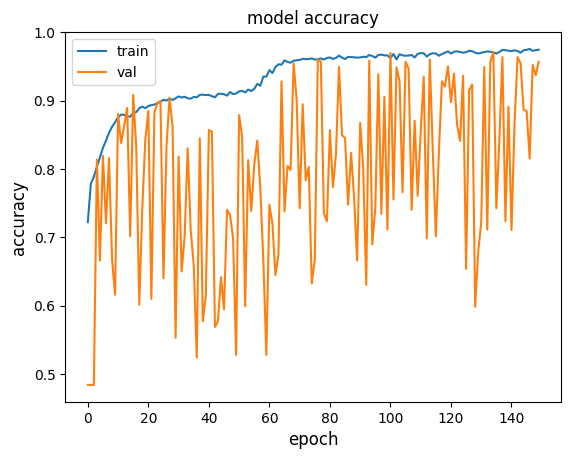

In [10]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()